# <font color="darkblue"> Prática 01: Classificação Linear - Regressão Logística </font>

**Objetivos:**


*   Implementar o modelo linear de *Regressão Logística*
*   Comparar seu resultado de classificiação linear com o LRClassifier

**Requisitos de execução:**


*   Upload dos arquivos *random_input.py*, *linearregression.py* e *lrclassifier.py*

**Atividade 1:**

1. Gere $N=100$ pontos aleatórios com rótulos de classificação utilizando a classe RandomInput da Aula 14;

    

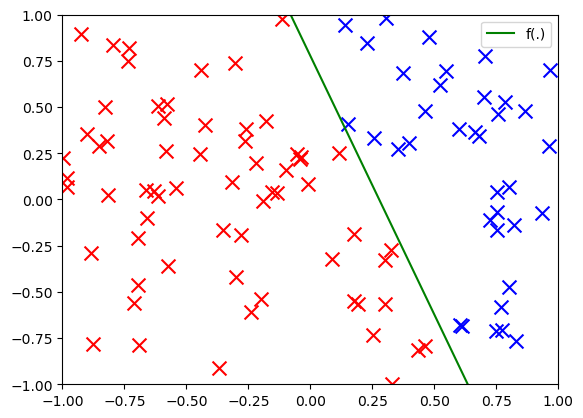

In [1]:
from random_input import RandomInput, draw
    
N = 100
rIN = RandomInput()
_X, _y = rIN.get_linear_input(N)
    
draw(_X, _y, rIN)

**Atividade 2:**

Implemente a *Regressão Logística* com o algoritmo *Gradiente Descendente*:

1. $w(0)=0$; $\eta = 0.1$;
2. **Para** $t=0,1,2..,tmax$ **faça**
3. $\quad\quad g_t=-\frac{1}{N}\sum_{n=1}^{N}\frac{y_nx_n}{1+e^{y_nw^T(t)x_n}}$;
4. $\quad\quad$ **Se** $(\lVert g_t \rVert < \epsilon)$ : **break**;
5. $\quad\quad w(t+1) = w(t) - \eta g_t$;
6. Retorne $w$


In [4]:
import numpy as np
from numpy import linalg as LA


class LogisticRegression_:
    def __init__(self, eta=0.1, tmax=1000, bs=1000000):
        self.eta = eta
        self.tmax = tmax
        self.batch_size = bs

    # Treinamento por Gradiente Descendente
    def fit(self, _X, _y, epsilon=1e-6):

        X = np.array(_X)
        y = np.array(_y)

        N = X.shape[0]
        d = X.shape[1]

        # w(0) = 0
        self.w = np.zeros(d)

        for t in range(self.tmax):

            # y_n * (w^T x_n)
            yz = y * (X @ self.w)

            # gradiente
            g = -(1 / N) * np.sum(
                (y[:, np.newaxis] * X) /
                (1 + np.exp(yz))[:, np.newaxis],
                axis=0
            )

            # critério de parada
            if LA.norm(g) < epsilon:
                break

            # atualização
            self.w = self.w - self.eta * g

        return self

    # Probabilidade P(y=1|x)
    def predict_prob(self, X):
        X = np.array(X)

        z = X @ self.w

        return 1 / (1 + np.exp(-z))

    # Classificação
    def predict(self, X):
        probs = self.predict_prob(X)

        return np.where(probs >= 0.5, 1, -1)

    def getW(self):
        return self.w

    def getRegressionY(self, regressionX, shift=0):
        return (-self.w[0] + shift - self.w[1] * regressionX) / self.w[2]

**Atividade 3:** 

1. Utilize o algoritmo de *Regressão Logística* para computar a função hipótese $g(x)=\theta(w^Tx)$ inferida sobre os pontos aleatórios gerados;
2. Plote, em um gráfico de dispersão, a probabilidade inferida pelo algoritmo em cada ponto;
3. Utilize a *Regressão Logística* como classificador linear e plote os pontos classificados com bolinha azul(1) e vermelha(0);
4. Compute o erro dentro da amostra gerado pela classificação linear do algoritmo de *Regressão Logistica*.


[3.01126106e-03 8.33625465e-02 1.22764650e-02 2.74335456e-01
 8.68118571e-01 4.89141855e-03 6.76031703e-02 4.30565246e-03
 2.73494631e-01 7.41111670e-03 1.40186184e-01 7.56707129e-01
 1.00999120e-03 9.92935582e-01 9.14946577e-01 2.61872531e-03
 7.64580199e-01 9.66197483e-01 2.84760109e-02 4.19131428e-02
 9.31475438e-01 4.71632718e-03 7.63576733e-03 9.14728260e-01
 9.47126415e-01 1.77206811e-02 1.47045897e-01 9.32622366e-01
 9.62109134e-01 3.24555985e-03 4.21989695e-01 1.84474674e-02
 1.40998507e-02 1.14942369e-03 2.02313487e-03 6.08965204e-01
 4.01591032e-01 1.49195234e-02 1.82156503e-02 6.15769230e-01
 1.55205580e-01 5.75514583e-03 1.86748739e-01 2.05120756e-01
 1.34766512e-01 7.13710071e-01 3.11353683e-02 2.53772239e-02
 6.21874560e-03 1.96873972e-01 1.84735467e-02 9.67069044e-01
 1.40534104e-03 9.39764084e-01 8.22349183e-02 3.65342978e-01
 9.84663362e-01 7.69200680e-01 1.63606680e-01 1.96465041e-01
 9.37238908e-01 8.18461407e-01 7.13538213e-03 1.72925286e-01
 8.68037679e-01 9.298936

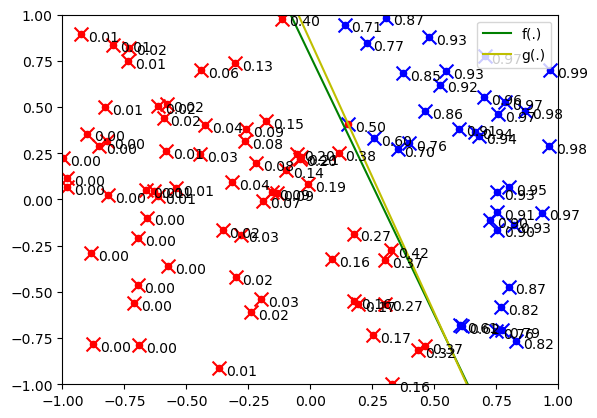

In [8]:
from matplotlib import pyplot as plt

draw(_X, _y, rIN)
rx = [ [1, x[0], x[1]] for x in _X]

#Executar o ajuste dos dados com Regressao Logistica
classifier = LogisticRegression_(0.1, 1000)
classifier.fit(rx, _y)

#Plota as porcentagens da Regressao Logistica 
pred = classifier.predict_prob(rx)
print(pred)

for x, pred_x in zip(_X, pred) :
  plt.annotate("{:.2f}".format(pred_x), xy=(x[0], x[1]), xytext=(5,-5), textcoords='offset points')

#desenha a reta inferida pela regressao logistica
xRL = [-1, +1]
yRL = [classifier.getRegressionY(xRL[0]), classifier.getRegressionY(xRL[1])]
plt.plot(xRL, yRL, 'y-', label='g(.)')
plt.legend(loc='upper right')

#plota os pontos classificados pela RL com bolinha azul(+) e vermelha(-)
xP = [_X[i][0] for i in range(N) if(pred[i] >= 0.5)]
yP = [_X[i][1] for i in range(N) if(pred[i] >= 0.5)]
xN = [_X[i][0] for i in range(N) if(pred[i] < 0.5)]
yN = [_X[i][1] for i in range(N) if(pred[i] < 0.5)]

plt.scatter(xP, yP, color='blue', marker='o', s=20)
plt.scatter(xN, yN, color='red', marker='o', s=20)

#Computando o erro dentro da amostra (Ein)
pred = classifier.predict(rx)

errorIN = 0
for pn, yn in zip(pred, _y):
  if(pn != yn):
    errorIN += 1
eIn_logistica = errorIN / N
print("Error in : " + str(errorIN/N * 100) + "%")


**Atividade 4:**

1. Reproduza o mesmo experimento para o classificador linear com Regressão Linear (*RCClassifier*);
2. Implemente o algoritmo *Gradiente Descendente Estocástico* na classe *LogisticRegression_* e compare os resultados.

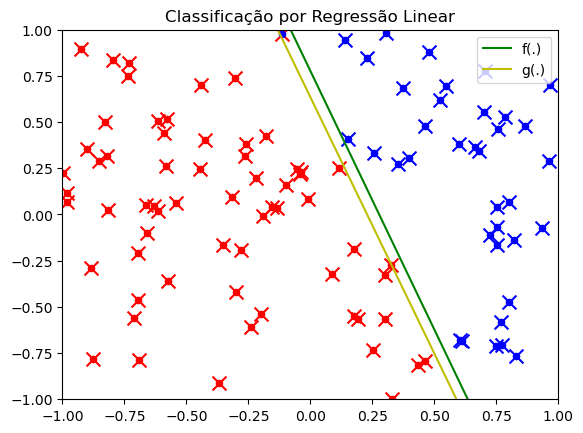

Ein = 1.00%


In [9]:
from lrclassifier import LRClassifier
from matplotlib import pyplot as plt

# Treina o classificador por Regressão Linear
classifier = LRClassifier()
classifier.fit(rx, _y)

# Desenha os dados originais
draw(_X, _y, rIN)

# Desenha a reta inferida
xRL = [-1, +1]
yRL = [
    classifier.getRegressionY(xRL[0]),
    classifier.getRegressionY(xRL[1])
]

plt.plot(xRL, yRL, 'y-', label='g(.)')
plt.legend(loc='upper right')

# Classificação dos pontos
pred = classifier.predict(rx)

# Pontos classificados como positivos
xP = [_X[i][0] for i in range(N) if pred[i] > 0]
yP = [_X[i][1] for i in range(N) if pred[i] > 0]

# Pontos classificados como negativos
xN = [_X[i][0] for i in range(N) if pred[i] < 0]
yN = [_X[i][1] for i in range(N) if pred[i] < 0]

# Plota classificação
plt.scatter(xP, yP, color='blue', marker='o', s=20)
plt.scatter(xN, yN, color='red', marker='o', s=20)

plt.title("Classificação por Regressão Linear")
plt.show()

# Computando Ein
eIn = 0

for yp, yt in zip(pred, _y):
    if yp != yt:
        eIn += 1

eIn /= N
eIn_linear = eIn
print("Ein = {:.2f}%".format(eIn * 100))

In [10]:
print("\n===== COMPARAÇÃO =====")
print("Ein Regressão Logística : {:.2f}%".format(eIn_logistica * 100))
print("Ein Regressão Linear    : {:.2f}%".format(eIn_linear * 100))

if eIn_logistica < eIn_linear:
    print("A Regressão Logística apresentou menor erro.")
elif eIn_logistica > eIn_linear:
    print("A Regressão Linear apresentou menor erro.")
else:
    print("Os dois métodos apresentaram o mesmo erro.")


===== COMPARAÇÃO =====
Ein Regressão Logística : 1.00%
Ein Regressão Linear    : 1.00%
Os dois métodos apresentaram o mesmo erro.


Atividade 5:

1. Reproduza o mesmo experimento com a classe LogisticRegression do pacote *sklearn.linear_model*
        from sklearn.linear_model import LogisticRegression

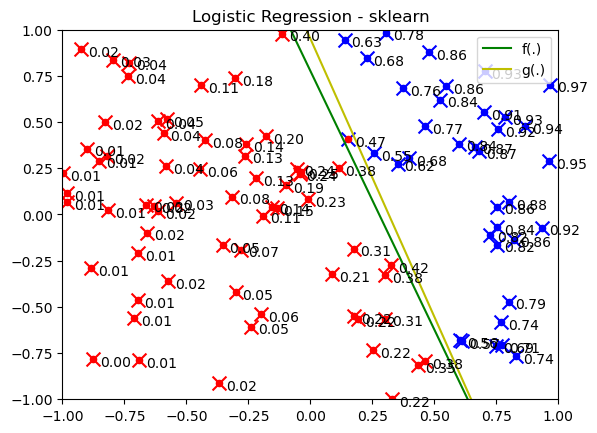

Ein (sklearn) = 1.00%


In [11]:
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot as plt
import numpy as np

draw(_X, _y, rIN)

# Treinamento
classifier = LogisticRegression(max_iter=1000)
classifier.fit(rx, _y)

# Probabilidades
prob = classifier.predict_proba(rx)

for x, p in zip(_X, prob):
    plt.annotate(
        "{:.2f}".format(p[1]),  # probabilidade da classe positiva
        xy=(x[0], x[1]),
        xytext=(5, -5),
        textcoords='offset points'
    )

# Coeficientes da reta
w0 = classifier.intercept_[0]
w1 = classifier.coef_[0][1]
w2 = classifier.coef_[0][2]

# reta: w0 + w1*x + w2*y = 0
xRL = [-1, 1]
yRL = [
    (-w0 - w1*xRL[0])/w2,
    (-w0 - w1*xRL[1])/w2
]

plt.plot(xRL, yRL, 'y-', label='g(.)')
plt.legend(loc='upper right')

# Classificação
pred = classifier.predict(rx)

xP = [_X[i][0] for i in range(N) if pred[i] > 0]
yP = [_X[i][1] for i in range(N) if pred[i] > 0]

xN = [_X[i][0] for i in range(N) if pred[i] < 0]
yN = [_X[i][1] for i in range(N) if pred[i] < 0]

plt.scatter(xP, yP, color='blue', marker='o', s=20)
plt.scatter(xN, yN, color='red', marker='o', s=20)

plt.title("Logistic Regression - sklearn")
plt.show()

# Ein
errorIN = 0

for pn, yn in zip(pred, _y):
    if pn != yn:
        errorIN += 1

eIn_sklearn = errorIN / N

print("Ein (sklearn) = {:.2f}%".format(eIn_sklearn * 100))

In [12]:
print("\n===== COMPARAÇÃO FINAL =====")
print("Regressão Linear      : {:.2f}%".format(eIn_linear * 100))
print("Logística (implement.) : {:.2f}%".format(eIn_logistica * 100))
print("Logística (sklearn)    : {:.2f}%".format(eIn_sklearn * 100))


===== COMPARAÇÃO FINAL =====
Regressão Linear      : 1.00%
Logística (implement.) : 1.00%
Logística (sklearn)    : 1.00%
